In [ ]:
import pandas as pd
import requests
import json

#usgs api address for lake level data
usgs_url = "https://waterservices.usgs.gov/nwis/dv/"

usgs_params = {
    "format": "json",    # we want it returned in json
    "sites": "10010000",    # Great Salt Lake at Saltair Boat Harbor, UT - USGS-10010000
    "parameterCd": "62614",   # code for lake water surface elevation
    "startDT": "1950-01-01",   # start and end dates
    "endDT": "2024-12-31"
}

#getting data from the api address with the params we set above
usgs_response = requests.get(usgs_url, params=usgs_params)
#converting to json
usgs_data = usgs_response.json()

# save the full json to a file
with open("usgs_response.json", "w") as f:
    json.dump(usgs_data, f, indent=2)


saved!


In [ ]:
# grabbing the tags where the data lives
usgs_time_series = usgs_data["value"]["timeSeries"][0]["values"][0]["value"]

usgs_df = pd.DataFrame(usgs_time_series)
print(usgs_df.head(20))
print(usgs_df.shape)

      value qualifiers                 dateTime
0   4197.15        [A]  1950-01-01T00:00:00.000
1   4197.40        [A]  1950-02-01T00:00:00.000
2   4197.90        [A]  1950-03-01T00:00:00.000
3   4198.15        [A]  1950-04-01T00:00:00.000
4   4198.35        [A]  1950-05-01T00:00:00.000
5   4198.80        [A]  1950-06-01T00:00:00.000
6   4198.65        [A]  1950-07-01T00:00:00.000
7   4198.30        [A]  1950-08-01T00:00:00.000
8   4197.90        [A]  1950-09-01T00:00:00.000
9   4197.55        [A]  1950-10-01T00:00:00.000
10  4197.60        [A]  1950-11-01T00:00:00.000
11  4197.90        [A]  1950-12-01T00:00:00.000
12  4198.30        [A]  1951-01-01T00:00:00.000
13  4198.50        [A]  1951-02-01T00:00:00.000
14  4198.95        [A]  1951-03-01T00:00:00.000
15  4199.20        [A]  1951-04-01T00:00:00.000
16  4199.45        [A]  1951-05-01T00:00:00.000
17  4199.90        [A]  1951-06-01T00:00:00.000
18  4199.55        [A]  1951-07-01T00:00:00.000
19  4199.15        [A]  1951-08-01T00:00

In [ ]:

# Clean up the dataframe
usgs_df = usgs_df.rename(columns={"dateTime": "date", "value": "elevation_ft"})
usgs_df["date"] = pd.to_datetime(usgs_df["date"])
usgs_df["elevation_ft"] = pd.to_numeric(usgs_df["elevation_ft"], errors="coerce")

# Add some useful columns
usgs_df["year"] = usgs_df["date"].dt.year
usgs_df["month"] = usgs_df["date"].dt.month

print(usgs_df.head(10))
print(usgs_df.dtypes)
print(usgs_df.describe())

   elevation_ft       date  year  month
0       4197.15 1950-01-01  1950      1
1       4197.40 1950-02-01  1950      2
2       4197.90 1950-03-01  1950      3
3       4198.15 1950-04-01  1950      4
4       4198.35 1950-05-01  1950      5
5       4198.80 1950-06-01  1950      6
6       4198.65 1950-07-01  1950      7
7       4198.30 1950-08-01  1950      8
8       4197.90 1950-09-01  1950      9
9       4197.55 1950-10-01  1950     10
elevation_ft           float64
date            datetime64[ns]
year                     int32
month                    int32
dtype: object
       elevation_ft                           date          year         month
count  13708.000000                          13708  13708.000000  13708.000000
mean    4196.964291  2005-03-29 10:14:00.385176448   2004.740881      6.550846
min     4188.500000            1950-01-01 00:00:00   1950.000000      1.000000
25%     4194.100000            1996-11-07 18:00:00   1996.000000      4.000000
50%     4196.410000        

In [ ]:
usgs_df.to_csv('lake_level.csv', index=False)

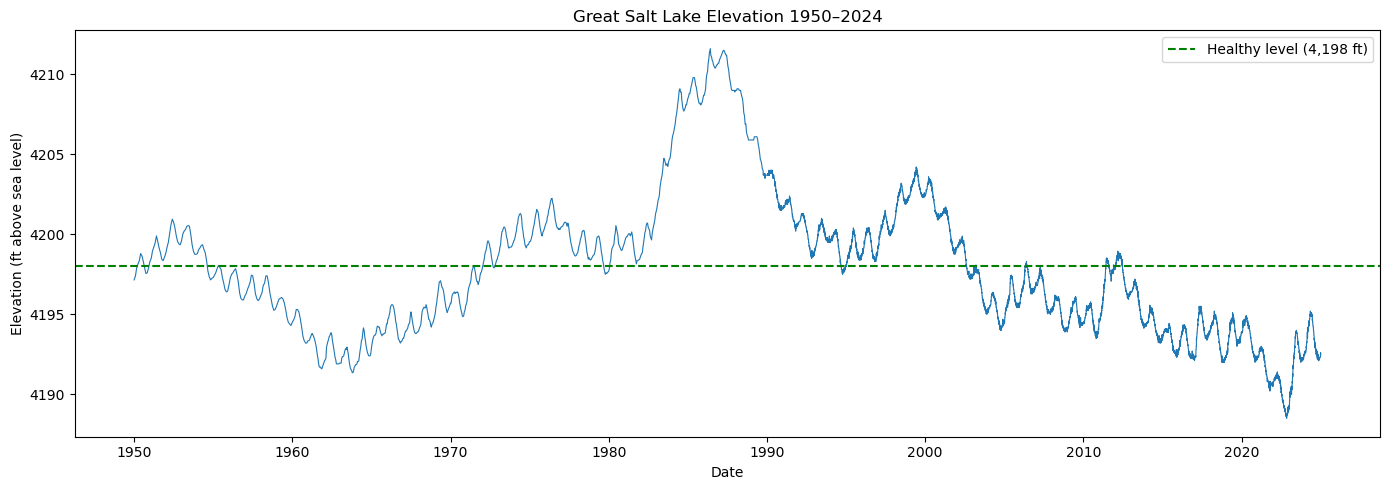

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))
plt.plot(usgs_df["date"], usgs_df["elevation_ft"], linewidth=0.8)
plt.axhline(y=4198, color="green", linestyle="--", label="Healthy level (4,198 ft)")
plt.title("Great Salt Lake Elevation 1950–2024")
plt.ylabel("Elevation (ft above sea level)")
plt.xlabel("Date")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:

my_token = "mkJhLVkURqcDlUNOaTCKtkLqZhSJBxou"

url = "https://www.ncei.noaa.gov/cdo-web/api/v2/stations"

params = {
    "datasetid": "GHCND",        # daily summaries dataset
    "datatypeid": "PRCP",        # precipitation
    "locationid": "FIPS:49",     # 49 is Utah's FIPS code
    "startdate": "1950-01-01",
    "enddate": "2024-12-31",
    "limit": 100
}

headers = {"token": my_token}

response = requests.get(url, params=params, headers=headers)
data = response.json()

stations_df = pd.DataFrame(data["results"])
print(stations_df[["id", "name", "latitude", "longitude", "mindate", "maxdate"]])

                   id                       name   latitude   longitude  \
0   GHCND:US1UTBE0002  BRIGHAM CITY 1.2 N, UT US  41.526700 -112.005000   
1   GHCND:US1UTBE0003     THATCHER 0.2 NE, UT US  41.702480 -112.297411   
2   GHCND:US1UTBE0004   TREMONTON 0.3 ENE, UT US  41.716678 -112.171474   
3   GHCND:US1UTBE0005  HONEYVILLE 0.5 NNE, UT US  41.640448 -112.077956   
4   GHCND:US1UTBE0006    THATCHER 1.7 ESE, UT US  41.694725 -112.267479   
..                ...                        ...        ...         ...   
95  GHCND:US1UTIR0003  CEDAR CITY 6.2 NNW, UT US  37.775300 -113.107300   
96  GHCND:US1UTIR0005   CEDAR CITY 4.4 SW, UT US  37.643100 -113.128400   
97  GHCND:US1UTIR0010   NEWCASTLE 0.6 SSW, UT US  37.662171 -113.553778   
98  GHCND:US1UTIR0011   CEDAR CITY 5.6 NW, UT US  37.750257 -113.142552   
99  GHCND:US1UTIR0012     PAROWAN 0.5 NNW, UT US  37.839243 -112.822288   

       mindate     maxdate  
0   2008-06-30  2025-02-01  
1   2008-09-01  2026-02-24  
2   2008-09-

In [16]:
import time
my_token = "mkJhLVkURqcDlUNOaTCKtkLqZhSJBxou"

headers = {"token": my_token}
url = "https://www.ncei.noaa.gov/cdo-web/api/v2/data"

all_data = []

for year in range(1950, 2025):
    params = {
        "datasetid": "GHCND",
        "stationid": "GHCND:USW00024127",
        "datatypeid": "PRCP",
        "startdate": f"{year}-01-01",
        "enddate": f"{year}-12-31",
        "limit": 1000,
        "units": "standard"
    }
    
    response = requests.get(url, params=params, headers=headers)
    
    if response.status_code == 200:
        data = response.json()
        if "results" in data:
            all_data.extend(data["results"])
            print(f"{year}: got {len(data['results'])} records")
        else:
            print(f"{year}: no results")
    else:
        print(f"{year}: error {response.status_code}")
    
    time.sleep(0.2)  # be polite to the API, don't hammer it

df_precip = pd.DataFrame(all_data)
print(df_precip.head(10))
print(df_precip.shape)



1950: got 365 records
1951: got 365 records
1952: got 366 records
1953: got 365 records
1954: got 365 records
1955: got 365 records
1956: got 366 records
1957: got 365 records
1958: got 365 records
1959: got 365 records
1960: got 366 records
1961: got 365 records
1962: got 365 records
1963: got 365 records
1964: got 366 records
1965: got 365 records
1966: got 365 records
1967: got 365 records
1968: got 366 records
1969: got 365 records
1970: got 365 records
1971: got 365 records
1972: got 366 records
1973: got 365 records
1974: got 365 records
1975: got 365 records
1976: got 366 records
1977: got 365 records
1978: got 365 records
1979: got 365 records
1980: got 366 records
1981: got 365 records
1982: got 365 records
1983: got 365 records
1984: got 366 records
1985: got 365 records
1986: got 365 records
1987: got 365 records
1988: got 366 records
1989: got 365 records
1990: got 365 records
1991: got 365 records
1992: got 366 records
1993: got 365 records
1994: got 365 records
1995: got 

In [17]:
# Clean up the precipitation dataframe
df_precip = df_precip.rename(columns={"date": "date", "value": "precip_inches"})
df_precip["date"] = pd.to_datetime(df_precip["date"])
df_precip["precip_inches"] = pd.to_numeric(df_precip["precip_inches"], errors="coerce")

# NOAA stores precip in tenths of mm even with "standard" units sometimes
# Check the scale - if values look way too small divide by 10
print(df_precip["precip_inches"].describe())

# Aggregate to annual totals since that's what we'll model with
df_precip_annual = df_precip.groupby(df_precip["date"].dt.year)["precip_inches"].sum().reset_index()
df_precip_annual.columns = ["year", "annual_precip"]

print(df_precip_annual.head(10))

count    27394.000000
mean         0.042465
std          0.129107
min          0.000000
25%          0.000000
50%          0.000000
75%          0.010000
max          2.280000
Name: precip_inches, dtype: float64
   year  annual_precip
0  1950          13.49
1  1951          17.50
2  1952          15.14
3  1953          12.32
4  1954          12.43
5  1955          13.63
6  1956          12.39
7  1957          18.44
8  1958          10.72
9  1959          13.82


In [18]:
print(df_precip_annual.head(10))
print(f"Average annual precipitation: {df_precip_annual['annual_precip'].mean():.2f} inches")

   year  annual_precip
0  1950          13.49
1  1951          17.50
2  1952          15.14
3  1953          12.32
4  1954          12.43
5  1955          13.63
6  1956          12.39
7  1957          18.44
8  1958          10.72
9  1959          13.82
Average annual precipitation: 15.51 inches


In [20]:
df_precip_annual.to_csv('annual_precip.csv', index=False)